<h1><center>Hand Gesture Classification using HaGRID dataset & MediaPipe</center></h1>


In [2]:
# importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
# reading the dataset & displaying the first few rows
df = pd.read_csv('hand_landmarks_data.csv')
df.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,y4,z4,x5,y5,z5,x6,y6,z6,x7,y7,z7,x8,y8,z8,x9,y9,z9,x10,y10,z10,x11,y11,z11,x12,y12,z12,x13,y13,z13,x14,y14,z14,x15,y15,z15,x16,y16,z16,x17,y17,z17,x18,y18,z18,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,262.669968,257.304901,-3.649205e-07,257.417542,247.109055,0.004224,246.882957,241.716827,0.005798,236.384537,241.453918,0.005872,230.076668,243.947525,0.005236,238.130150,233.234192,0.000154,225.652794,247.249207,-0.003813,226.056931,255.866364,-0.006753,228.159897,260.384155,-0.007799,236.882492,238.052338,-0.004955,226.113327,252.712662,-0.010097,229.431679,260.451080,-0.014108,232.641357,265.248962,-0.016854,236.293053,244.317657,-0.009528,225.111259,256.214203,-0.016194,227.390144,263.649139,-0.020701,230.754410,268.069519,-0.023142,236.512527,251.706177,-0.013198,223.345093,255.490692,-0.020450,215.043365,258.114746,-0.024577,208.006393,259.608673,-0.026722,call
1,83.351778,346.059113,-2.345265e-07,81.925037,328.562347,-0.011102,90.080132,311.535248,-0.021096,95.641823,298.860626,-0.029252,94.470360,287.298767,-0.034743,108.349709,308.093719,-0.022332,126.623394,317.461853,-0.033495,120.436695,321.913879,-0.039811,113.516293,320.967957,-0.044990,112.661499,318.378937,-0.024038,126.470741,326.580048,-0.032438,119.046581,329.816071,-0.033811,114.183495,329.230194,-0.036610,115.033024,330.221741,-0.026222,129.401276,335.143341,-0.034942,123.797516,337.128418,-0.030081,118.561386,336.647949,-0.027561,116.245079,341.947784,-0.029042,132.451618,341.794434,-0.038175,142.773582,342.829254,-0.037336,152.431698,343.015991,-0.036136,call
2,187.756977,260.235492,-2.417307e-07,195.460579,241.506035,-0.000184,207.259529,223.674339,-0.009687,215.413628,209.035360,-0.020580,214.772873,196.609588,-0.029497,227.154053,225.576852,-0.016897,245.390419,237.862886,-0.023851,239.404152,244.408742,-0.024241,232.023811,244.865198,-0.024215,229.581985,237.329024,-0.025533,245.673843,248.809410,-0.029864,238.769005,254.638094,-0.027649,231.852882,253.995576,-0.027500,230.325073,251.093664,-0.033584,246.591980,260.490353,-0.038898,240.098305,265.280085,-0.033344,233.025467,264.505473,-0.030234,230.100174,265.584175,-0.041256,250.301010,268.602938,-0.044068,262.425133,271.276638,-0.040469,272.989952,272.272231,-0.038301,call
3,114.976696,331.594238,-1.233261e-07,114.503494,320.549957,-0.002824,116.636627,310.080994,-0.008911,117.685066,301.874115,-0.015029,116.766609,294.977814,-0.019514,129.777031,308.501129,-0.010413,139.635818,310.151733,-0.016497,136.397449,312.745758,-0.020082,131.874081,313.205322,-0.023151,132.963112,315.039551,-0.014133,141.762932,315.943848,-0.018309,138.536854,317.723969,-0.019228,134.968494,319.064636,-0.021387,134.844761,322.039795,-0.017837,143.293087,322.025909,-0.021707,140.613567,323.325195,-0.018406,137.043560,324.407806,-0.017291,135.485836,329.050110,-0.021804,145.195450,329.357544,-0.027622,151.053200,329.712341,-0.027863,155.990364,329.548828,-0.027723,call
4,188.795288,141.727867,-1.622995e-07,188.520905,127.947464,-0.002884,191.982880,111.010563,-0.008115,192.552521,98.687691,-0.013397,188.239563,90.394289,-0.017483,202.827484,110.826588,-0.013008,219.390350,112.392162,-0.019843,215.733658,117.425114,-0.022405,210.229782,118.631218,-0.024263,206.339752,118.629364,-0.016029,221.155609,120.211258,-0.021682,217.215561,124.373337,-0.022350,212.064911,125.186268,-0.023731,209.829666,126.978264,-0.018826,223.595139,127.696289,-0.023907,219.652115,130.917194,-0.020978,214.071228,131.502628,-0.019323,213.105820,135.293209,-0.021623,226.696396,132.263248,-0.025113,234.831741,130.684147,-0.024087,241.587769,128.477188,-0.023486,call


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25675 entries, 0 to 25674
Data columns (total 64 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      25675 non-null  float64
 1   y1      25675 non-null  float64
 2   z1      25675 non-null  float64
 3   x2      25675 non-null  float64
 4   y2      25675 non-null  float64
 5   z2      25675 non-null  float64
 6   x3      25675 non-null  float64
 7   y3      25675 non-null  float64
 8   z3      25675 non-null  float64
 9   x4      25675 non-null  float64
 10  y4      25675 non-null  float64
 11  z4      25675 non-null  float64
 12  x5      25675 non-null  float64
 13  y5      25675 non-null  float64
 14  z5      25675 non-null  float64
 15  x6      25675 non-null  float64
 16  y6      25675 non-null  float64
 17  z6      25675 non-null  float64
 18  x7      25675 non-null  float64
 19  y7      25675 non-null  float64
 20  z7      25675 non-null  float64
 21  x8      25675 non-null  float64
 22

In [5]:
df['label'].unique()

array(['call', 'dislike', 'fist', 'four', 'like', 'mute', 'ok', 'one',
       'palm', 'peace', 'peace_inverted', 'rock', 'stop', 'stop_inverted',
       'three', 'three2', 'two_up', 'two_up_inverted'], dtype=object)

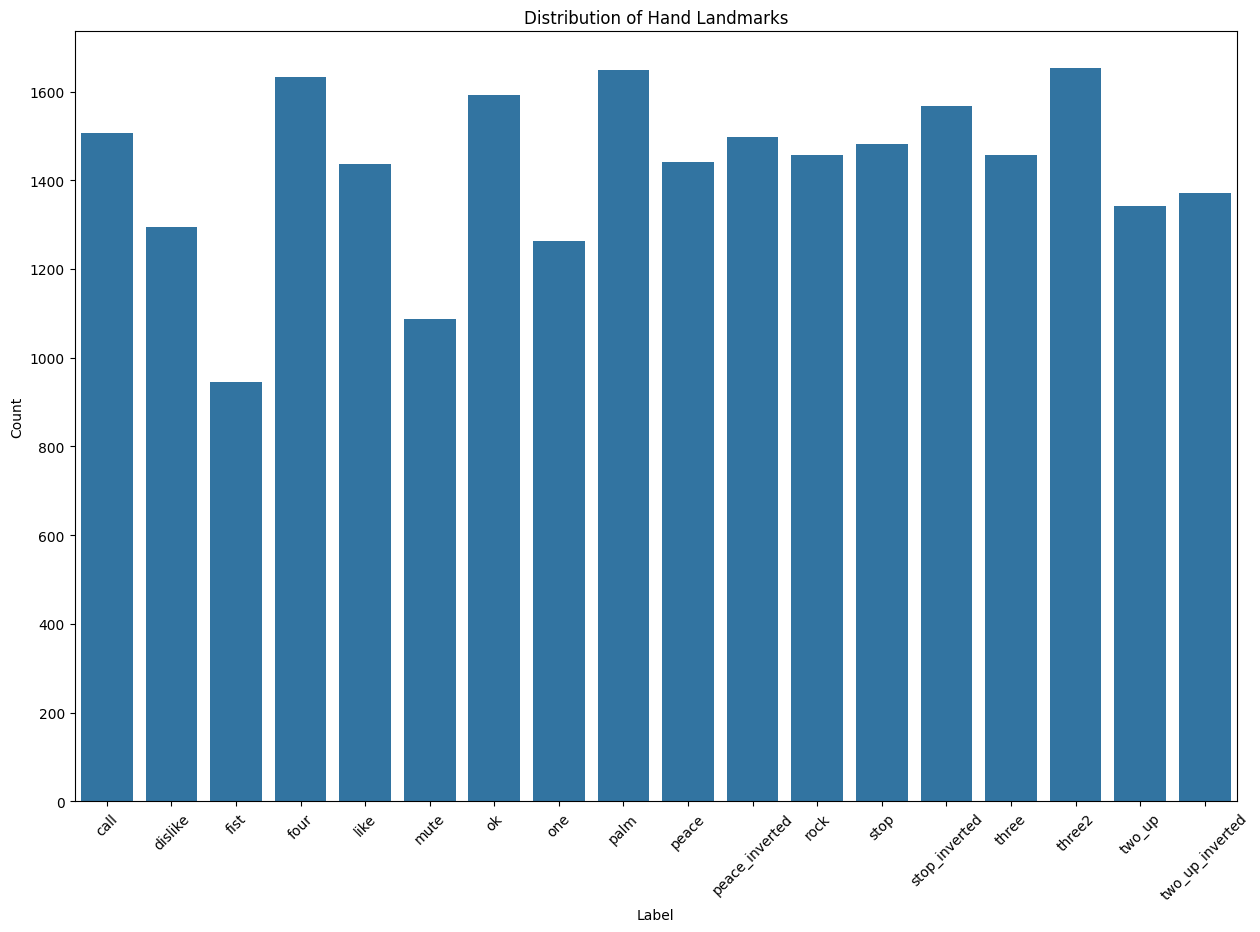

In [6]:
# checking the distribution of the 'label' column
fig = plt.figure(figsize=(15, 10))
sns.countplot(x='label', data=df)
plt.title('Distribution of Hand Landmarks')
plt.xlabel('Label')
plt.ylabel('Count') 
plt.xticks(rotation=45)
plt.show()

In [7]:
df['label'].value_counts()

label
three2             1653
palm               1649
four               1634
ok                 1592
stop_inverted      1567
call               1506
peace_inverted     1497
stop               1482
rock               1458
three              1456
peace              1441
like               1436
two_up_inverted    1371
two_up             1343
dislike            1295
one                1263
mute               1087
fist                945
Name: count, dtype: int64

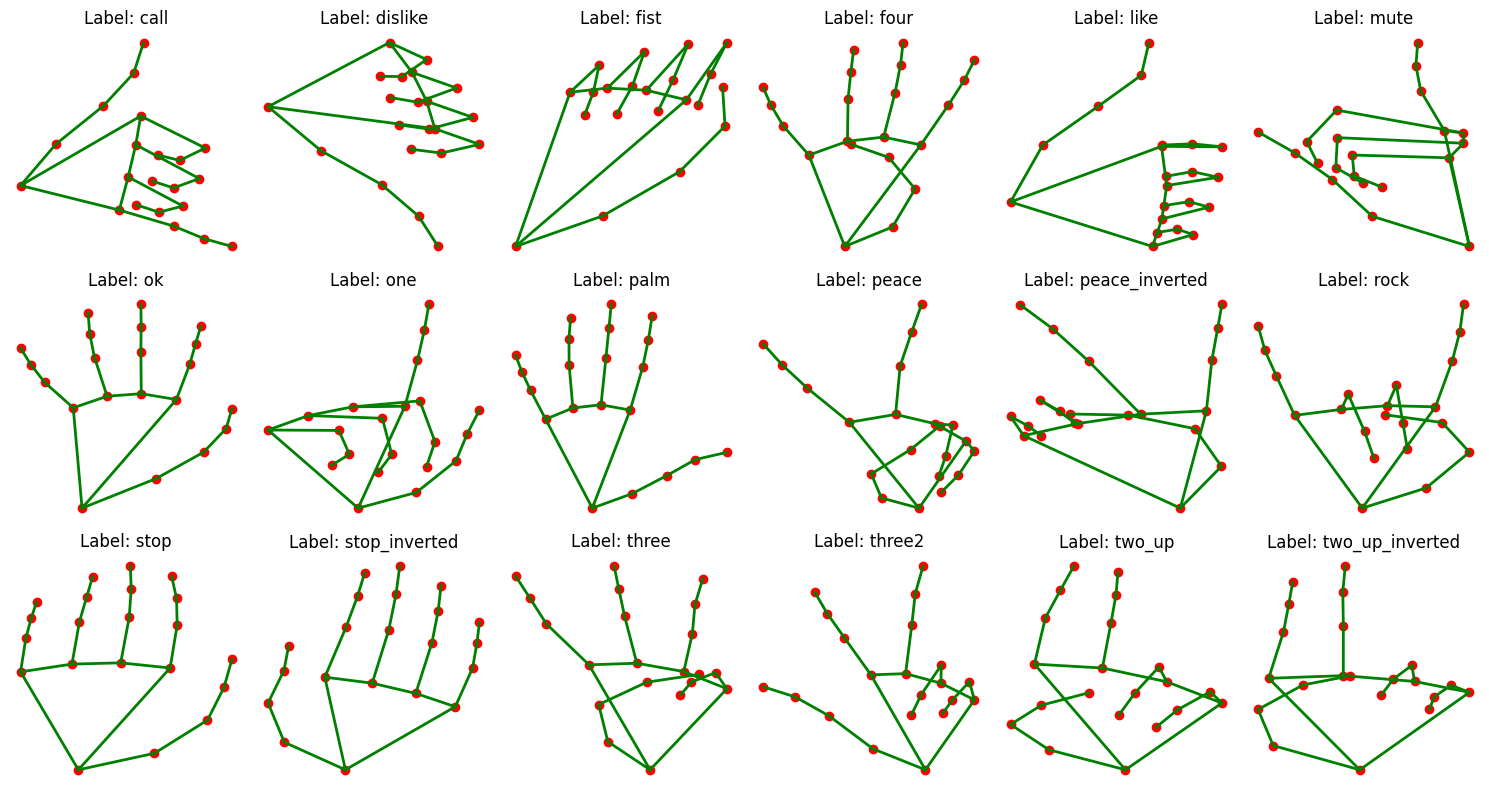

In [8]:

# Select one row per label
sampled_df = df.groupby("label").sample().reset_index()

# Number of landmarks
num_landmarks = 21

# Define hand landmark edges (MediaPipe structure)
edges = [
    (0, 1), (1, 2), (2, 3), (3, 4),  # Thumb
    (0, 5), (5, 6), (6, 7), (7, 8),  # Index
    (0, 17), (17, 18), (18, 19), (19, 20),  # Pinky
    (5, 9), (9, 10), (10, 11), (11, 12),  # Middle
    (9, 13), (13, 14), (14, 15), (15, 16),  # Ring
    (13, 17)  # Palm base connection
]

# Plot all sampled gestures
fig, axes = plt.subplots(3, 6, figsize=(15, 8))  # Adjust grid based on the number of labels
axes = axes.flatten() 

for i, row in sampled_df.iterrows():
    ax = axes[i]
    
    # Extract (x, y) coordinates
    x_values = [row[f"x{j+1}"] for j in range(num_landmarks)]
    y_values = [row[f"y{j+1}"] for j in range(num_landmarks)]

    # Plot hand landmarks
    ax.scatter(x_values, y_values, color='red', label="Landmarks")

    # Draw edges
    for edge in edges:
        x_start, y_start = x_values[edge[0]], y_values[edge[0]]
        x_end, y_end = x_values[edge[1]], y_values[edge[1]]
        ax.plot([x_start, x_end], [y_start, y_end], color="green", linewidth=2)

    # Annotate gesture label
    ax.set_title(f"Label: {row['label']}")
    ax.invert_yaxis()  # Invert y-axis for correct orientation
    ax.axis("off")  # Hide axis for better visualization

plt.tight_layout()
plt.show()


In [9]:
# Process each row in the dataset
def normalize_landmarks(row):
    # Wrist coordinates (Landmark 0)
    wrist_x, wrist_y = row["x1"], row["y1"]
    # Middle fingertip coordinates (Landmark 12)
    mid_finger_x, mid_finger_y = row["x13"], row["y13"]
    # Compute scaling factor (distance from wrist to middle fingertip)
    scale = np.sqrt((mid_finger_x - wrist_x) ** 2 + (mid_finger_y - wrist_y) ** 2)
    
    # Avoid division by zero
    if scale == 0:
        scale = 1
    # Normalize each landmark
    for i in range(num_landmarks):
        row[f"x{i+1}"] = (row[f"x{i+1}"] - wrist_x) / scale
        row[f"y{i+1}"] = (row[f"y{i+1}"] - wrist_y) / scale

    return row

# Apply normalization
df_normalized = df.apply(normalize_landmarks, axis=1)

In [10]:
df_normalized.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,y4,z4,x5,y5,z5,x6,y6,z6,x7,y7,z7,x8,y8,z8,x9,y9,z9,x10,y10,z10,x11,y11,z11,x12,y12,z12,x13,y13,z13,x14,y14,z14,x15,y15,z15,x16,y16,z16,x17,y17,z17,x18,y18,z18,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,0.0,0.0,-3.649205e-07,-0.169097,-0.328246,0.004224,-0.508248,-0.501843,0.005798,-0.846234,-0.510307,0.005872,-1.049310,-0.430028,0.005236,-0.790036,-0.774934,0.000154,-1.191733,-0.323734,-0.003813,-1.178722,-0.046312,-0.006753,-1.111019,0.099134,-0.007799,-0.830203,-0.619818,-0.004955,-1.176906,-0.147843,-0.010097,-1.070075,0.101288,-0.014108,-0.966743,0.255751,-0.016854,-0.849180,-0.418112,-0.009528,-1.209167,-0.035114,-0.016194,-1.135800,0.204247,-0.020701,-1.027491,0.346557,-0.023142,-0.842114,-0.180246,-0.013198,-1.266027,-0.058407,-0.020450,-1.533293,0.026072,-0.024577,-1.759842,0.074168,-0.026722,call
1,0.0,0.0,-2.345265e-07,-0.040618,-0.498120,-0.011102,0.191551,-0.982869,-0.021096,0.349889,-1.343706,-0.029252,0.316538,-1.672864,-0.034743,0.711673,-1.080847,-0.022332,1.231911,-0.814143,-0.033495,1.055781,-0.687397,-0.039811,0.858762,-0.714327,-0.044990,0.834426,-0.788034,-0.024038,1.227565,-0.554555,-0.032438,1.016205,-0.462428,-0.033811,0.877756,-0.479107,-0.036610,0.901942,-0.450878,-0.026222,1.310996,-0.310764,-0.034942,1.151461,-0.254250,-0.030081,1.002392,-0.267929,-0.027561,0.936448,-0.117047,-0.029042,1.397837,-0.121412,-0.038175,1.691695,-0.091952,-0.037336,1.966655,-0.086635,-0.036136,call
2,0.0,0.0,-2.417307e-07,0.172978,-0.420554,-0.000184,0.437913,-0.820949,-0.009687,0.621006,-1.149655,-0.020580,0.606619,-1.428665,-0.029497,0.884627,-0.778230,-0.016897,1.294109,-0.502358,-0.023851,1.159693,-0.355376,-0.024241,0.993974,-0.345127,-0.024215,0.939145,-0.514345,-0.025533,1.300473,-0.256563,-0.029864,1.145431,-0.125685,-0.027649,0.990136,-0.140112,-0.027500,0.955830,-0.205272,-0.033584,1.321089,0.005723,-0.038898,1.175280,0.113272,-0.033344,1.016465,0.095879,-0.030234,0.950780,0.120100,-0.041256,1.404373,0.187884,-0.044068,1.676609,0.247919,-0.040469,1.913833,0.270275,-0.038301,call
3,0.0,0.0,-1.233261e-07,-0.020056,-0.468103,-0.002824,0.070355,-0.911821,-0.008911,0.114792,-1.259663,-0.015029,0.075864,-1.551957,-0.019514,0.627300,-0.978783,-0.010413,1.045157,-0.908823,-0.016497,0.907901,-0.798877,-0.020082,0.716182,-0.779399,-0.023151,0.762340,-0.701657,-0.014133,1.135313,-0.663329,-0.018309,0.998578,-0.587880,-0.019228,0.847336,-0.531057,-0.021387,0.842092,-0.404957,-0.017837,1.200167,-0.405546,-0.021707,1.086598,-0.350477,-0.018406,0.935286,-0.304591,-0.017291,0.869263,-0.107831,-0.021804,1.280797,-0.094800,-0.027622,1.529073,-0.079763,-0.027863,1.738331,-0.086693,-0.027723,call
4,0.0,0.0,-1.622995e-07,-0.009611,-0.482677,-0.002884,0.111650,-1.075914,-0.008115,0.131602,-1.507539,-0.013397,-0.019465,-1.798027,-0.017483,0.491496,-1.082358,-0.013008,1.071633,-1.027522,-0.019843,0.943552,-0.851236,-0.022405,0.750772,-0.808991,-0.024263,0.614518,-0.809056,-0.016029,1.133463,-0.753648,-0.021682,0.995458,-0.607865,-0.022350,0.815049,-0.579391,-0.023731,0.736757,-0.516624,-0.018826,1.218911,-0.491475,-0.023907,1.080801,-0.378658,-0.020978,0.885323,-0.358153,-0.019323,0.851509,-0.225382,-0.021623,1.327537,-0.331511,-0.025113,1.612488,-0.386821,-0.024087,1.849127,-0.464123,-0.023486,call


In [11]:
label_encoder = LabelEncoder()

df_normalized["label_encoded"] = label_encoder.fit_transform(df_normalized["label"])

# Check encoding
print(df_normalized[["label", "label_encoded"]].head())

#decoded_label = label_encoder.inverse_transform([0])  # Converts 0 back to original label


  label  label_encoded
0  call              0
1  call              0
2  call              0
3  call              0
4  call              0


In [12]:
df_normalized.drop(columns=["label"], inplace=True)
df_normalized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25675 entries, 0 to 25674
Data columns (total 64 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   x1             25675 non-null  float64
 1   y1             25675 non-null  float64
 2   z1             25675 non-null  float64
 3   x2             25675 non-null  float64
 4   y2             25675 non-null  float64
 5   z2             25675 non-null  float64
 6   x3             25675 non-null  float64
 7   y3             25675 non-null  float64
 8   z3             25675 non-null  float64
 9   x4             25675 non-null  float64
 10  y4             25675 non-null  float64
 11  z4             25675 non-null  float64
 12  x5             25675 non-null  float64
 13  y5             25675 non-null  float64
 14  z5             25675 non-null  float64
 15  x6             25675 non-null  float64
 16  y6             25675 non-null  float64
 17  z6             25675 non-null  float64
 18  x7    

In [13]:
df_normalized['label_encoded'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17])

In [14]:
label_encoder.inverse_transform(df_normalized['label_encoded'].unique())

array(['call', 'dislike', 'fist', 'four', 'like', 'mute', 'ok', 'one',
       'palm', 'peace', 'peace_inverted', 'rock', 'stop', 'stop_inverted',
       'three', 'three2', 'two_up', 'two_up_inverted'], dtype=object)

In [15]:
features = df_normalized.drop(["label_encoded"], axis=1)
labels = df_normalized["label_encoded"]

In [16]:
features.shape

(25675, 63)

In [17]:
labels.shape

(25675,)

In [18]:
# Splitting the dataset into training and validation/test sets
# 60% training, 40% validation/test
features_train, features_validation_test, labels_train, labels_validation_test = train_test_split(
    features, labels, test_size=0.4, random_state=100)

In [19]:
# Splitting the validation/test set into two equal parts
features_validation, features_test, labels_validation, labels_test = train_test_split(
    features_validation_test, labels_validation_test, test_size=0.5, random_state=100)

In [20]:
print(len(features_train))
print(len(features_validation))
print(len(features_test))
print(len(labels_train))
print(len(labels_validation))
print(len(labels_test))

15405
5135
5135
15405
5135
5135


<h2><center>Training Different Models</center></h2>


In [21]:
# Train logistic regression model
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(multi_class="multinomial")
lr_model.fit(features_train,labels_train)
lr_model_score = lr_model.score(features_validation,labels_validation)

/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [22]:
# Train decision tree model
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier()
dt_model.fit(features_train,labels_train)
dt_model_score = dt_model.score(features_validation,labels_validation)

In [23]:
# Train SVM model
from sklearn.svm import SVC
svm_model = SVC()
svm_model.fit(features_train,labels_train)
svm_model_score = svm_model.score(features_validation,labels_validation)

In [24]:
# Train random forest model
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(features_train,labels_train)
rf_model_score = rf_model.score(features_validation,labels_validation)

In [25]:
# Train gradient boosting model
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier()
gb_model.fit(features_train,labels_train)
gb_model_score = gb_model.score(features_validation,labels_validation)

In [26]:
# Train Adaboost model
from sklearn.ensemble import AdaBoostClassifier
ab_model = AdaBoostClassifier()
ab_model.fit(features_train,labels_train)
ab_model_score = ab_model.score(features_validation,labels_validation)

/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [27]:
# print accuracy of each model on validation data
print("Scores of the models",)
print("Logistic regression:",lr_model_score)
print("Decision tree:",dt_model_score )
print("SVM:", svm_model_score)
print("Random forest:",rf_model_score )
print("Gradient boosting:",gb_model_score )
print("AdaBoost:",ab_model_score )

Scores of the models
Logistic regression: 0.8385589094449853
Decision tree: 0.9456669912366115
SVM: 0.9180136319376826
Random forest: 0.9776046738072055
Gradient boosting: 0.9748782862706913
AdaBoost: 0.1851996105160662


In [28]:
from sklearn.metrics import recall_score, precision_score
print("Precision of the models",)
print("Logistic regression:",precision_score(labels_validation, lr_model.predict(features_validation),average='weighted'))
print("Decision tree:",precision_score(labels_validation, dt_model.predict(features_validation),average='weighted'))
print("SVM:", precision_score(labels_validation, svm_model.predict(features_validation),average='weighted'))
print("Random forest:",precision_score(labels_validation, rf_model.predict(features_validation),average='weighted'))
print("Gradient boosting:",precision_score(labels_validation, gb_model.predict(features_validation),average='weighted'))
print("AdaBoost:",precision_score(labels_validation, ab_model.predict(features_validation),average='weighted'))

Precision of the models
Logistic regression: 0.8396808319136294
Decision tree: 0.9459433167116525
SVM: 0.9196804261446018
Random forest: 0.9777105214557358
Gradient boosting: 0.9749905777887063
AdaBoost: 0.16814144030120964


/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
print("Recall of the models",)
print("Logistic regression:",recall_score(labels_validation, lr_model.predict(features_validation),average='weighted'))
print("Decision tree:",recall_score(labels_validation, dt_model.predict(features_validation),average='weighted'))
print("SVM:", recall_score(labels_validation, svm_model.predict(features_validation),average='weighted'))
print("Random forest:",recall_score(labels_validation, rf_model.predict(features_validation),average='weighted'))
print("Gradient boosting:",recall_score(labels_validation, gb_model.predict(features_validation),average='weighted'))
print("AdaBoost:",recall_score(labels_validation, ab_model.predict(features_validation),average='weighted'))

Recall of the models
Logistic regression: 0.8385589094449853
Decision tree: 0.9456669912366115
SVM: 0.9180136319376826
Random forest: 0.9776046738072055
Gradient boosting: 0.9748782862706913
AdaBoost: 0.1851996105160662


In [30]:
# print F1-score of each model on validation data
from sklearn.metrics import f1_score
print("F1-scores of the models:")
lr_f1=f1_score(labels_validation,lr_model.predict(features_validation),average='weighted')
print("Logistic regression:",lr_f1 )
dt_f1=f1_score(labels_validation,dt_model.predict(features_validation),average='weighted')
print("Decision tree:",dt_f1 )
svm_f1=f1_score(labels_validation,svm_model.predict(features_validation),average='weighted')
print("SVM:",svm_f1 )
rf_f1=f1_score(labels_validation,rf_model.predict(features_validation),average='weighted')
print("Random forest:",rf_f1 )
gb_f1=f1_score(labels_validation,gb_model.predict(features_validation),average='weighted')
print("Gradient boosting:",gb_f1 )
ab_f1=f1_score(labels_validation,ab_model.predict(features_validation),average='weighted')
print("AdaBoost:",ab_f1 )

F1-scores of the models:
Logistic regression: 0.836106372257509
Decision tree: 0.9457060659179711
SVM: 0.917688345846663
Random forest: 0.9776039696119003
Gradient boosting: 0.9748758586084865
AdaBoost: 0.09973064215297643


In [31]:
#rf_model
# Prediction score on test data
print(rf_model.score(features_test,labels_test))

0.973904576436222


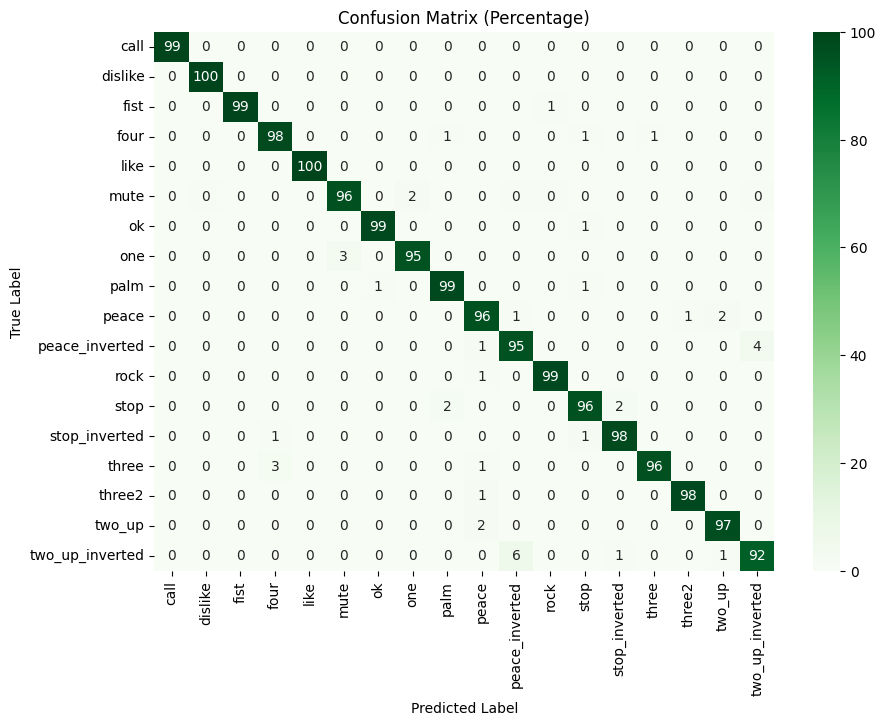

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = rf_model.predict(features_test)

# Compute confusion matrix
cm = confusion_matrix(labels_test, y_pred)

cm_percentage = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True) * 100  # Normalize per class

# Plot confusion matrix using seaborn
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percentage, annot=True, fmt=".0f", cmap="Greens", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)

# Labels and title
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Percentage)")
plt.show()

In [33]:
import joblib
joblib.dump(gb_model,"rf_model.pkl")

['rf_model.pkl']

<h3><center>training results<center><h3>


## From the metrics and the confusion matrix it is shown that the random forest model preforms the best

### Now we move from model training to model inference

#### first we need to use media pipe to extract the key points

#### then the data must pass through the same "pipeline" before making predictions


In [34]:
rf_model=joblib.load("rf_model.pkl")

In [36]:
!pip install mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 MB 3.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 1.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 MB 3.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 MB 2.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 2.9 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.3
    Uninstalling protobuf-5.29.3:
      Successfully uninstalled protobuf-5.29.3


In [37]:
import cv2
import mediapipe as mp

In [38]:
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=False,  # For video, set to False
                        max_num_hands=1,         # Detect one hand
                        min_detection_confidence=0.5, 
                        min_tracking_confidence=0.5)

# Initialize MediaPipe Drawing (for visualization)
mp_drawing = mp.solutions.drawing_utils

I0000 00:00:1743537712.661969  133663 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.3), renderer: Apple M1


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1743537712.684192  153538 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1743537712.692886  153538 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [42]:
cap = cv2.VideoCapture(1)
if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

while True:
    # Read a frame from the webcam
    ret, frame = cap.read()
    
    if not ret:
        print("Error: Failed to grab frame.")
        break
    
    cv2.imshow("Hand Tracking", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
cv2.destroyAllWindows()

In [45]:
cv2.destroyAllWindows()
cap.release()